# LAB 5-6: sieci splotowe CNN dla PlantVillage

Celem notatnika jest zbudowanie i przetestowanie sieci splotowej do klasyfikacji obrazów liści z bazy PlantVillage. Używamy tego samego wariantu danych co w zadaniu MLP: obrazy kolorowe oraz pierwsze 5 klas alfabetycznie z katalogu danych.

Zakres wykonania:

- wczytanie obrazów z co najmniej 5 klas,
- podział na zbiory treningowy, walidacyjny i testowy,
- augmentacja danych treningowych,
- model CNN w PyTorch,
- standardowe wizualizacje dokładnościowe,
- macierz pomyłek i raport klasyfikacji,
- wizualizacja filtrów splotowych pierwszej warstwy.

## 1. Import bibliotek i konfiguracja

Ustawiamy ziarna losowości, rozmiar obrazów i parametry eksperymentu. `MAX_IMAGES_PER_CLASS=600` odpowiada poprzedniemu notatnikowi MLP i skraca trening bez zmiany listy klas.

In [2]:
from pathlib import Path
import random
import time
from copy import deepcopy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Urządzenie:", DEVICE)

IMG_SIZE = 64
NUM_CLASSES = 5
MAX_IMAGES_PER_CLASS = 600
BATCH_SIZE = 32
EPOCHS = 10

Urządzenie: cpu


## 2. Lokalizacja danych

Dane w tym katalogu są w `archive (2)/plantvillage dataset/color`. Funkcja poniżej sprawdza kilka typowych ścieżek, żeby notatnik działał także po zmianie nazwy folderu.

In [3]:
def find_data_root():
    candidates = [
        Path("archive") / "plantvillage dataset" / "color",
        Path("archive (2)") / "plantvillage dataset" / "color",
        Path("plantvillage dataset") / "color",
        Path("plantvillage-dataset") / "plantvillage dataset" / "color",
        Path("plantvillage-dataset") / "color",
        Path(r"C:\Users\misie\Downloads\LAB5\archive (2)\plantvillage dataset\color"),
    ]
    for path in candidates:
        if path.exists() and any(child.is_dir() for child in path.iterdir()):
            return path
    raise FileNotFoundError("Nie znaleziono katalogu z obrazami PlantVillage.")

DATA_ROOT = find_data_root()
print("DATA_ROOT:", DATA_ROOT.resolve())

DATA_ROOT: C:\Users\misie\Downloads\LAB5\archive (2)\plantvillage dataset\color


## 3. Wczytanie danych i wybór tych samych 5 klas co w MLP

`ImageFolder` traktuje każdy podfolder jako jedną klasę. Wybieramy pierwsze 5 klas alfabetycznie, tak samo jak w poprzednim zadaniu MLP. Etykiety klas są potem przemapowane na zakres `0..4`.

In [6]:
base_dataset = datasets.ImageFolder(DATA_ROOT)
all_classes = base_dataset.classes

SELECTED_CLASSES = all_classes[:NUM_CLASSES]
selected_old_ids = [base_dataset.class_to_idx[class_name] for class_name in SELECTED_CLASSES]
old_to_new = {old_idx: new_idx for new_idx, old_idx in enumerate(selected_old_ids)}

selected_indices = []
per_class_counter = {old_idx: 0 for old_idx in selected_old_ids}

# Ograniczamy liczbę obrazów w każdej klasie, ale zachowujemy te same klasy co w MLP.
for sample_idx, (_, old_target) in enumerate(base_dataset.samples):
    if old_target in selected_old_ids:
        if MAX_IMAGES_PER_CLASS is None or per_class_counter[old_target] < MAX_IMAGES_PER_CLASS:
            selected_indices.append(sample_idx)
            per_class_counter[old_target] += 1

targets_new = np.array([old_to_new[base_dataset.samples[i][1]] for i in selected_indices])

print("Liczba wszystkich klas w PlantVillage:", len(all_classes))
print("Wybrane klasy:")
for i, class_name in enumerate(SELECTED_CLASSES):
    print(f"{i}: {class_name} ({sum(targets_new == i)} obrazów)")
print("Liczba obrazów w podzbiorze:", len(selected_indices))

Liczba wszystkich klas w PlantVillage: 38
Wybrane klasy:
0: Apple___Apple_scab (600 obrazów)
1: Apple___Black_rot (600 obrazów)
2: Apple___Cedar_apple_rust (275 obrazów)
3: Apple___healthy (600 obrazów)
4: Blueberry___healthy (600 obrazów)
Liczba obrazów w podzbiorze: 2675


## 4. Podział train/validation/test

Podział jest stratygraficzny, czyli zachowuje podobne proporcje klas w każdym zbiorze. To jest ważne przy klasyfikacji, bo wynik testowy nie powinien zależeć od przypadkowego braku którejś klasy.

In [7]:
train_idx, temp_idx, y_train, y_temp = train_test_split(
    selected_indices,
    targets_new,
    test_size=0.30,
    random_state=SEED,
    stratify=targets_new,
)

val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

print(f"Train: {len(train_idx)} | Validation: {len(val_idx)} | Test: {len(test_idx)}")

Train: 1872 | Validation: 401 | Test: 402


## 5. Transformacje i augmentacja

Augmentację stosujemy tylko dla zbioru treningowego. Walidacja i test muszą pokazywać realną jakość modelu, więc używają tylko resize, tensorowania i normalizacji.

In [8]:
class PlantVillageSubset(datasets.ImageFolder):
    def __init__(self, root, old_to_new, transform=None):
        super().__init__(root, transform=transform)
        self.old_to_new = old_to_new

    def __getitem__(self, index):
        image, old_target = super().__getitem__(index)
        return image, self.old_to_new[old_target]


def get_transforms(augment=False):
    train_steps = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
    if augment:
        train_steps += [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(20),
            transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.92, 1.08)),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
        ]
    train_steps += [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]

    eval_steps = [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
    return transforms.Compose(train_steps), transforms.Compose(eval_steps)


def make_loaders(batch_size=BATCH_SIZE, augment=True):
    train_transform, eval_transform = get_transforms(augment=augment)

    train_dataset = PlantVillageSubset(DATA_ROOT, old_to_new, transform=train_transform)
    val_dataset = PlantVillageSubset(DATA_ROOT, old_to_new, transform=eval_transform)
    test_dataset = PlantVillageSubset(DATA_ROOT, old_to_new, transform=eval_transform)

    return (
        DataLoader(Subset(train_dataset, train_idx), batch_size=batch_size, shuffle=True, num_workers=0),
        DataLoader(Subset(val_dataset, val_idx), batch_size=batch_size, shuffle=False, num_workers=0),
        DataLoader(Subset(test_dataset, test_idx), batch_size=batch_size, shuffle=False, num_workers=0),
    )

## 6. Podgląd danych

Najpierw sprawdzamy rozkład klas i przykładowe obrazy. To pozwala szybko wykryć błędną ścieżkę albo nieoczekiwany dobór klas.

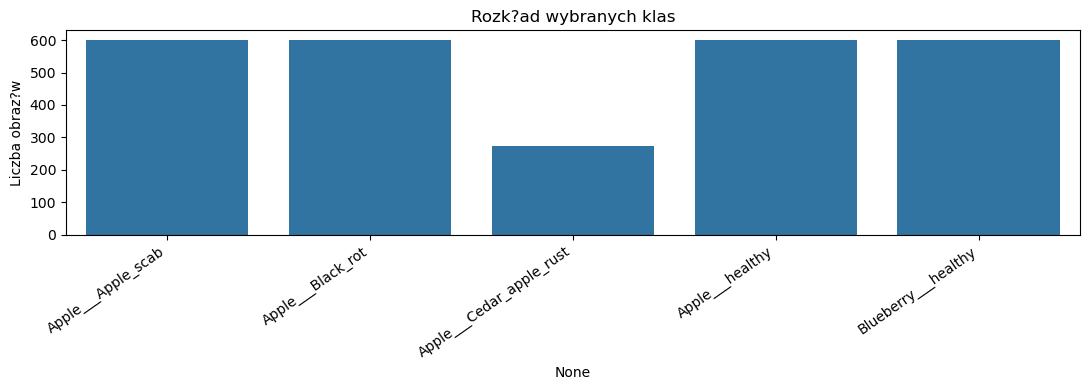

In [9]:
counts = pd.Series(targets_new).value_counts().sort_index()
counts.index = SELECTED_CLASSES

plt.figure(figsize=(11, 4))
sns.barplot(x=counts.index, y=counts.values)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Liczba obraz?w")
plt.title("Rozk?ad wybranych klas")
plt.tight_layout()
plt.show()

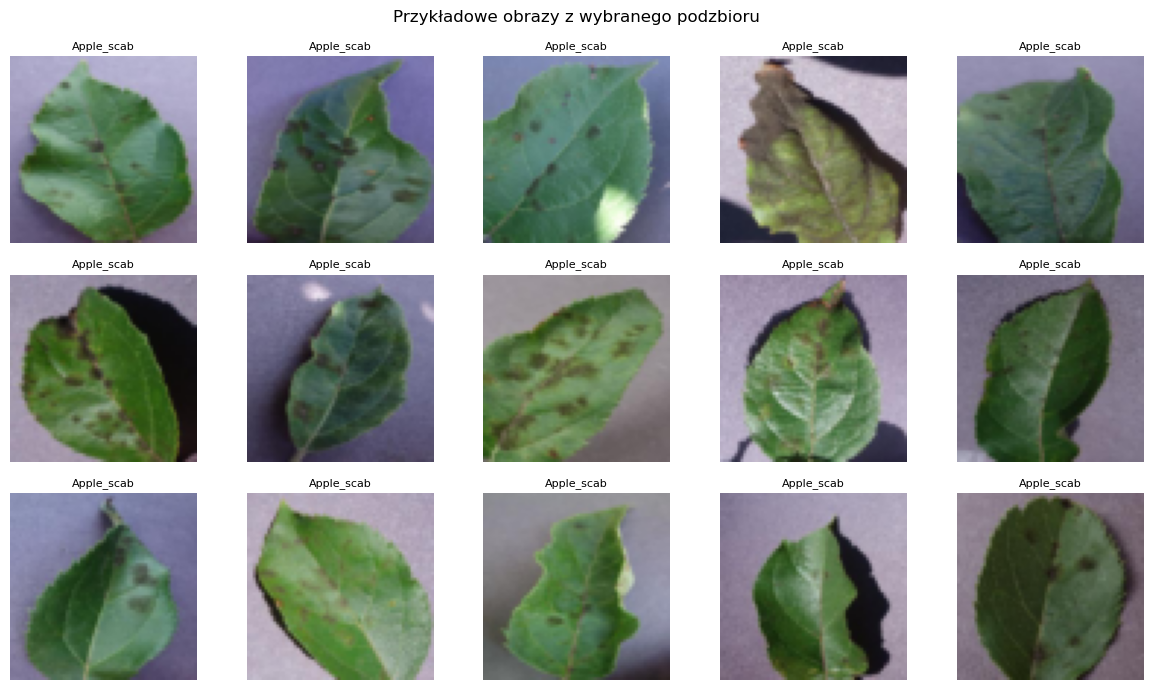

In [11]:
preview_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])
preview_dataset = datasets.ImageFolder(DATA_ROOT, transform=preview_transform)

plt.figure(figsize=(12, 7))
for plot_i, dataset_i in enumerate(selected_indices[:15], start=1):
    image, label = preview_dataset[dataset_i]
    plt.subplot(3, 5, plot_i)
    plt.imshow(image.permute(1, 2, 0))
    plt.title(all_classes[label].split("___")[-1], fontsize=8)
    plt.axis("off")
plt.suptitle("Przykładowe obrazy z wybranego podzbioru")
plt.tight_layout()
plt.show()

## 7. Wizualizacja augmentacji

Poniżej widać kilka losowych wariantów tego samego obrazu. Model dostaje dzięki temu większą różnorodność przykładów i zwykle mniej przeucza się na treningu.

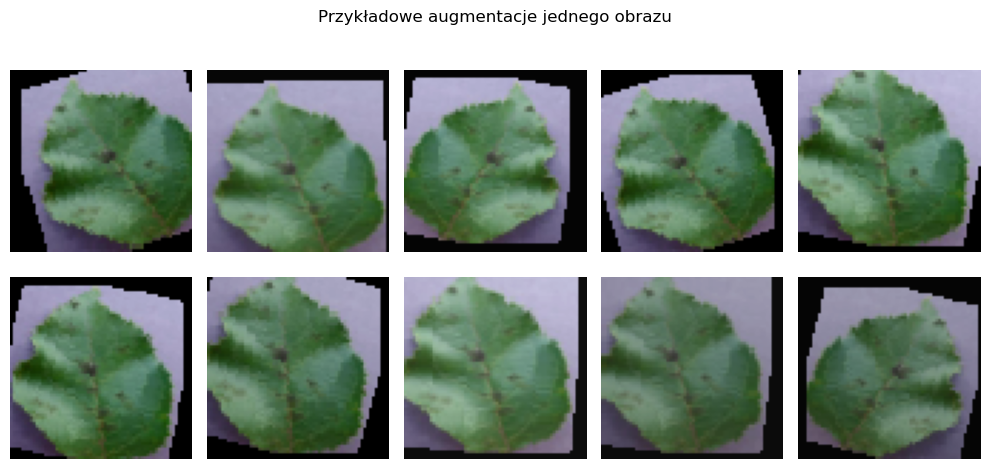

In [12]:
raw_image_path, _ = base_dataset.samples[selected_indices[0]]
raw_image = Image.open(raw_image_path).convert("RGB")

augmentation_preview = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.92, 1.08)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
])

plt.figure(figsize=(10, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(augmentation_preview(raw_image))
    plt.axis("off")
plt.suptitle("Przykładowe augmentacje jednego obrazu")
plt.tight_layout()
plt.show()

## 8. Model CNN

CNN nie spłaszcza obrazu od razu jak MLP. Warstwy splotowe uczą się lokalnych cech, takich jak krawędzie, plamy, przebarwienia i tekstury liści. Pooling zmniejsza mapy cech, a klasyfikator na końcu zamienia cechy na prawdopodobieństwa klas.

In [13]:
class LeafCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=5, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (IMG_SIZE // 8) * (IMG_SIZE // 8), 128),
            nn.ReLU(),
            nn.Dropout(0.35),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = LeafCNN().to(DEVICE)
print(model)

LeafCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=

## 9. Funkcje treningu i ewaluacji

`run_epoch` działa w dwóch trybach. Jeżeli dostanie optimizer, uczy model. Jeżeli optimizer jest `None`, tylko liczy stratę i dokładność.

In [14]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    context = torch.enable_grad() if is_training else torch.no_grad()
    with context:
        for x, y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            if is_training:
                optimizer.zero_grad()

            logits = model(x)
            loss = criterion(logits, y)

            if is_training:
                loss.backward()
                optimizer.step()

            batch_size = x.size(0)
            total_loss += loss.item() * batch_size
            correct += (logits.argmax(dim=1) == y).sum().item()
            total += batch_size

    return total_loss / total, correct / total


def train_model(epochs=EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, augment=True):
    train_loader, val_loader, test_loader = make_loaders(batch_size=batch_size, augment=augment)
    model = LeafCNN().to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    history = []
    best_state = None
    best_val_acc = -1.0
    start = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = deepcopy(model.state_dict())

        print(
            f"Epoka {epoch:02d}: "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    model.load_state_dict(best_state)
    test_loss, test_acc = run_epoch(model, test_loader, criterion)
    elapsed = time.time() - start
    print(f"Najlepsza walidacja: {best_val_acc:.4f}")
    print(f"Test: loss={test_loss:.4f}, acc={test_acc:.4f}")
    print(f"Czas treningu: {elapsed:.1f} s")

    return model, pd.DataFrame(history), test_acc

## 10. Trening CNN z augmentacją

Wynik testowy liczymy dopiero po zakończeniu treningu, na najlepszym stanie modelu według dokładności walidacyjnej.

In [15]:
cnn_model, history, test_acc = train_model(epochs=EPOCHS, batch_size=BATCH_SIZE, lr=1e-3, augment=True)
history

Epoka 01: train_loss=1.2632, train_acc=0.4936, val_loss=0.6654, val_acc=0.7855
Epoka 02: train_loss=0.6943, train_acc=0.7484, val_loss=0.2976, val_acc=0.9027
Epoka 03: train_loss=0.5336, train_acc=0.8248, val_loss=0.4643, val_acc=0.8254
Epoka 04: train_loss=0.4367, train_acc=0.8478, val_loss=0.2903, val_acc=0.8953
Epoka 05: train_loss=0.4119, train_acc=0.8600, val_loss=0.1891, val_acc=0.9302
Epoka 06: train_loss=0.3937, train_acc=0.8729, val_loss=0.1486, val_acc=0.9526
Epoka 07: train_loss=0.3406, train_acc=0.8771, val_loss=0.1675, val_acc=0.9426
Epoka 08: train_loss=0.3220, train_acc=0.8916, val_loss=0.1901, val_acc=0.9377
Epoka 09: train_loss=0.3388, train_acc=0.8798, val_loss=0.1731, val_acc=0.9526
Epoka 10: train_loss=0.2895, train_acc=0.9001, val_loss=0.2704, val_acc=0.9002
Najlepsza walidacja: 0.9526
Test: loss=0.1818, acc=0.9303
Czas treningu: 207.6 s


,epoch,train_loss,train_acc,val_loss,val_acc
0,1,1.263194,0.493590,0.665438,0.785536
1,2,0.694342,0.748397,0.297575,0.902743
2,3,0.533623,0.824786,0.464276,0.825436
3,4,0.436656,0.847756,0.290341,0.895262
4,5,0.411891,0.860043,0.189106,0.930175
5,6,0.393747,0.872863,0.148575,0.952618
6,7,0.340636,0.877137,0.167539,0.942643
7,8,0.321978,0.891560,0.190146,0.937656
8,9,0.338840,0.879808,0.173055,0.952618
9,10,0.289522,0.900107,0.270449,0.900249


## 11. Wizualizacje dokładnościowe

Krzywe `loss` i `accuracy` pokazują, czy model się uczy oraz czy pojawia się przeuczenie. Duża różnica między train i validation accuracy sugeruje overfitting.

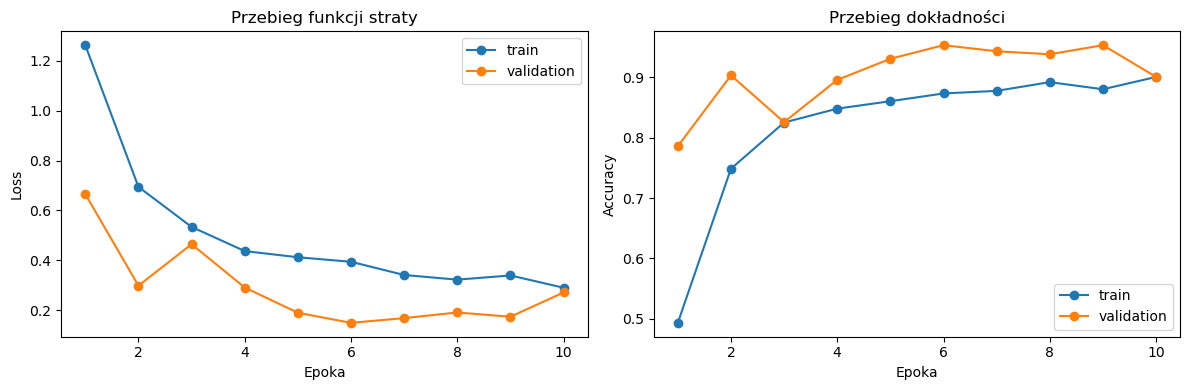

In [17]:
def plot_history(history_df):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation")
    axes[0].set_xlabel("Epoka")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Przebieg funkcji straty")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_acc"], marker="o", label="train")
    axes[1].plot(history_df["epoch"], history_df["val_acc"], marker="o", label="validation")
    axes[1].set_xlabel("Epoka")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Przebieg dokładności")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

## 12. Macierz pomyłek i raport klasyfikacji

Macierz pomyłek pokazuje, które klasy model rozróżnia dobrze, a które myli ze sobą. Raport podaje precision, recall i F1-score osobno dla każdej klasy.

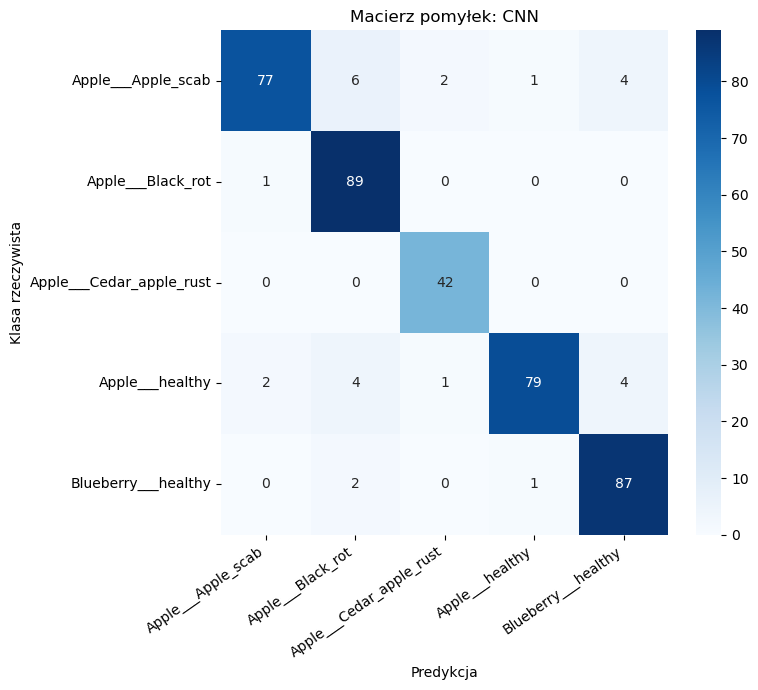

                          precision    recall  f1-score   support

      Apple___Apple_scab       0.96      0.86      0.91        90
       Apple___Black_rot       0.88      0.99      0.93        90
Apple___Cedar_apple_rust       0.93      1.00      0.97        42
         Apple___healthy       0.98      0.88      0.92        90
     Blueberry___healthy       0.92      0.97      0.94        90

                accuracy                           0.93       402
               macro avg       0.93      0.94      0.93       402
            weighted avg       0.93      0.93      0.93       402



In [19]:
def predict(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(DEVICE))
            y_pred.extend(logits.argmax(dim=1).cpu().numpy())
            y_true.extend(y.numpy())
    return np.array(y_true), np.array(y_pred)

_, _, test_loader = make_loaders(batch_size=64, augment=False)
y_true, y_pred = predict(cnn_model, test_loader)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SELECTED_CLASSES,
    yticklabels=SELECTED_CLASSES,
)
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.xlabel("Predykcja")
plt.ylabel("Klasa rzeczywista")
plt.title("Macierz pomyłek: CNN")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=SELECTED_CLASSES))

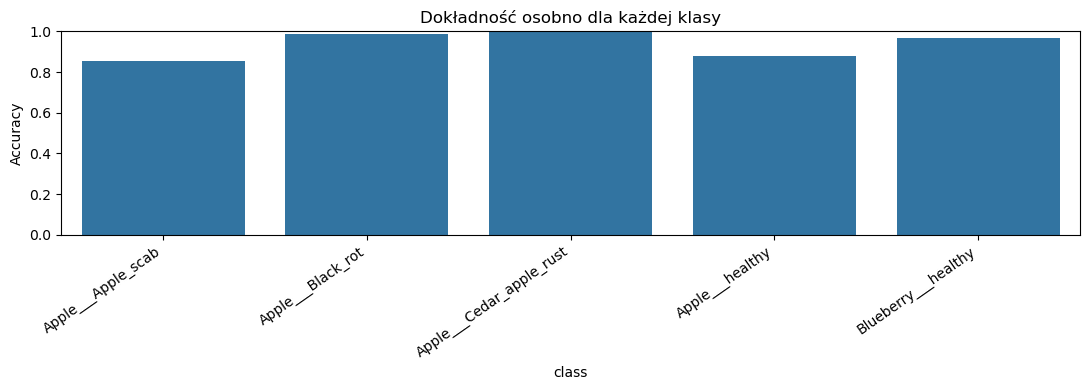

,class,accuracy
0,Apple___Apple_scab,0.855556
1,Apple___Black_rot,0.988889
2,Apple___Cedar_apple_rust,1.000000
3,Apple___healthy,0.877778
4,Blueberry___healthy,0.966667


In [20]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
per_class_df = pd.DataFrame({
    "class": SELECTED_CLASSES,
    "accuracy": per_class_acc,
})

plt.figure(figsize=(11, 4))
sns.barplot(data=per_class_df, x="class", y="accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.ylabel("Accuracy")
plt.title("Dokładność osobno dla każdej klasy")
plt.tight_layout()
plt.show()

per_class_df

## 13. Wizualizacja filtrów splotowych

Pierwsza warstwa splotowa ma filtry `5x5x3`. Każdy filtr można potraktować jak mały obraz RGB. Po treningu filtry zwykle reagują na proste lokalne wzorce: kontrast, krawędzie, plamy koloru i drobne tekstury.

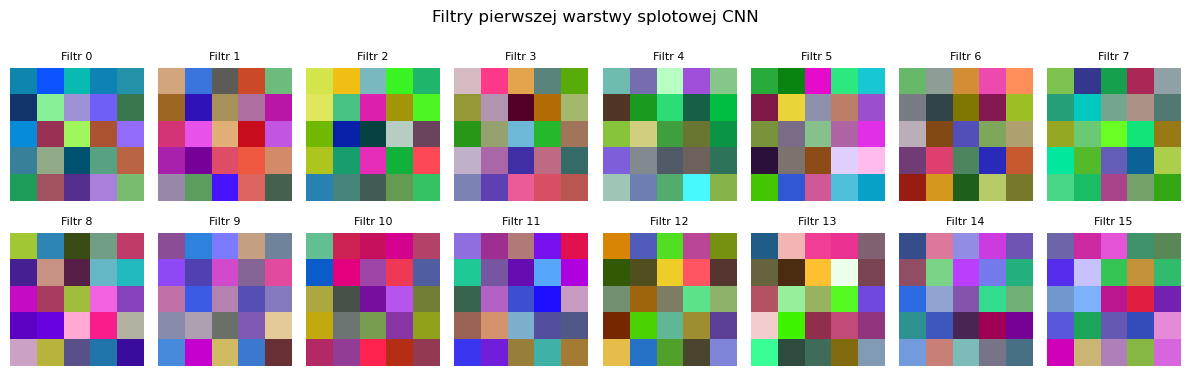

In [21]:
def show_first_layer_filters(model):
    first_conv = None
    for layer in model.features:
        if isinstance(layer, nn.Conv2d):
            first_conv = layer
            break

    if first_conv is None:
        raise ValueError("Model nie zawiera warstwy Conv2d.")

    weights = first_conv.weight.detach().cpu().clone()
    n_filters = weights.shape[0]
    n_cols = 8
    n_rows = int(np.ceil(n_filters / n_cols))

    plt.figure(figsize=(12, 2 * n_rows))
    for i in range(n_filters):
        filt = weights[i]
        # Przeskalowanie ka?dego filtra do zakresu 0..1 u?atwia wizualizacj?.
        filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-8)
        filt = filt.permute(1, 2, 0).numpy()

        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(filt)
        plt.title(f"Filtr {i}", fontsize=8)
        plt.axis("off")

    plt.suptitle("Filtry pierwszej warstwy splotowej CNN")
    plt.tight_layout()
    plt.show()

show_first_layer_filters(cnn_model)

## 14. Dodatkowo: mapy aktywacji pierwszej warstwy

Filtry są parametrami modelu, a mapy aktywacji pokazują, gdzie na konkretnym obrazie dany filtr zareagował najmocniej. To pomaga zrozumieć działanie sieci splotowej na przykładzie.

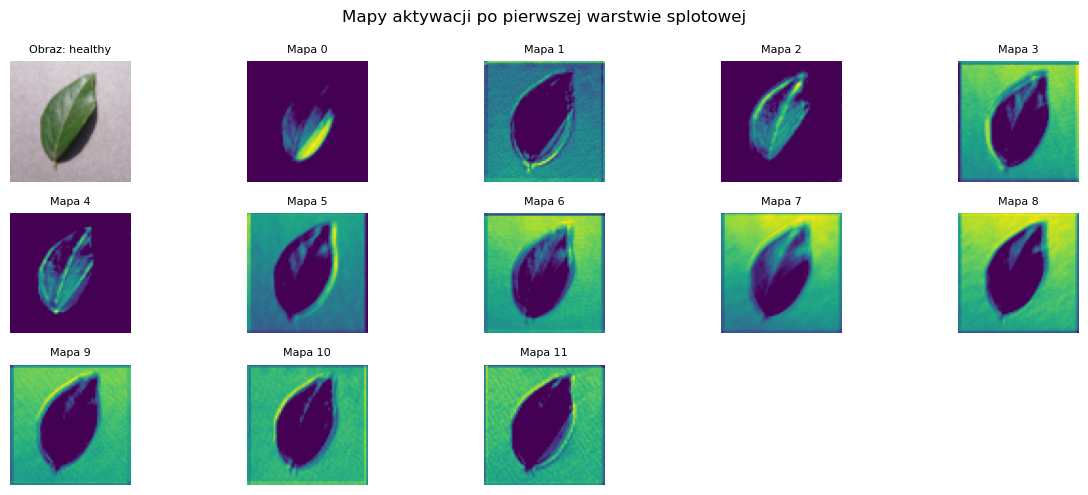

In [22]:
def denormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    image = tensor.cpu() * std + mean
    return image.clamp(0, 1)


def show_activation_maps(model, loader, max_maps=12):
    model.eval()
    x, y = next(iter(loader))
    image = x[0:1].to(DEVICE)
    true_label = y[0].item()

    first_block = nn.Sequential(*list(model.features.children())[:3]).to(DEVICE)
    with torch.no_grad():
        activations = first_block(image).cpu()[0]

    plt.figure(figsize=(12, 5))
    plt.subplot(3, 5, 1)
    plt.imshow(denormalize_image(x[0]).permute(1, 2, 0))
    plt.title(f"Obraz: {SELECTED_CLASSES[true_label].split('___')[-1]}", fontsize=8)
    plt.axis("off")

    for i in range(min(max_maps, activations.shape[0])):
        plt.subplot(3, 5, i + 2)
        plt.imshow(activations[i], cmap="viridis")
        plt.title(f"Mapa {i}", fontsize=8)
        plt.axis("off")

    plt.suptitle("Mapy aktywacji po pierwszej warstwie splotowej")
    plt.tight_layout()
    plt.show()

_, _, test_loader = make_loaders(batch_size=16, augment=False)
show_activation_maps(cnn_model, test_loader)

## 15. Podsumowanie wyników

Zapisujemy najważniejsze liczby do pliku CSV, żeby można było łatwo odnieść CNN do wyników z poprzedniego MLP.

In [23]:
summary = pd.DataFrame([{
    "model": "LeafCNN",
    "classes": NUM_CLASSES,
    "image_size": IMG_SIZE,
    "max_images_per_class": MAX_IMAGES_PER_CLASS,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "augmentation": True,
    "optimizer": "AdamW",
    "learning_rate": 1e-3,
    "test_accuracy": test_acc,
}])

summary.to_csv("wyniki_cnn_plantvillage_lab5_6.csv", index=False)
print("Zapisano: wyniki_cnn_plantvillage_lab5_6.csv")
summary

Zapisano: wyniki_cnn_plantvillage_lab5_6.csv


,model,classes,image_size,max_images_per_class,batch_size,epochs,augmentation,optimizer,learning_rate,test_accuracy
0,LeafCNN,5,64,600,32,10,True,AdamW,0.001,0.930348
